In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t
import yfinance as yf
from scipy.optimize import minimize_scalar


In [149]:
#chargement des donnés de l'actif S&P500

data = yf.download(
    "^GSPC",
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = data["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed


In [150]:
prices

,^GSPC
Date,
2018-01-02,2695.810059
2018-01-03,2713.060059
2018-01-04,2723.989990
2018-01-05,2743.149902
2018-01-08,2747.709961
...,...
2025-12-24,6932.049805
2025-12-26,6929.939941
2025-12-29,6905.740234


#Calcul des rendements

Le rendement entre les dates $t-1$ et $t$ est donné par: $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [151]:
returns = np.log(prices / prices.shift(1)).dropna()

In [152]:
returns

,^GSPC
Date,
2018-01-03,0.006378
2018-01-04,0.004021
2018-01-05,0.007009
2018-01-08,0.001661
2018-01-09,0.001302
...,...
2025-12-24,0.003216
2025-12-26,-0.000304
2025-12-29,-0.003498


Analyse descriptive

In [153]:
print(returns.describe())

count    2010.000000
mean        0.000464
std         0.012382
min        -0.127652
25%        -0.004460
50%         0.000905
75%         0.006512
max         0.090895
Name: ^GSPC, dtype: float64


In [154]:
def estimate_ewma_lambda(returns):
    # Nettoyage
    r = np.asarray(returns.dropna(), dtype=float)

    # Centrage des rendements
    r = r - np.mean(r)

    # Variance initiale
    initial_variance = np.var(r, ddof=1)

    def negative_log_likelihood(lam):

        variances = np.empty(len(r))
        variances[0] = initial_variance
        for t in range(1, len(r)):
            variances[t] = (lam * variances[t - 1] + (1 - lam) * r[t - 1]**2)
        variances = np.maximum(variances, 1e-12)

        # Log-vraisemblance normale
        log_likelihood = -0.5 * np.sum(np.log(2 * np.pi)+ np.log(variances) + r**2 / variances)

        return -log_likelihood

    # Optimisation de lambda
    result = minimize_scalar(negative_log_likelihood,bounds=(0.80, 0.999), method="bounded")

    return result.x


In [155]:
lamba1=estimate_ewma_lambda(returns)
lamba1

np.float64(0.9084578550023078)

#Calcule la volatilité EWMA.

In [156]:
def ewma_volatility(returns, lamb=lamba1):

    returns = pd.Series(returns).dropna()

    variances= np.zeros(len(returns))

    # Initialisation avec la variance historique
    variances[0] = returns.var()

    for i in range(1, len(returns)):
        variances[i] = (
            lamb * variances[i - 1]
            + (1 - lamb) * returns.iloc[i - 1] ** 2
        )

    volatility = np.sqrt(variances)

    return pd.Series(
        volatility,
        index=returns.index,
        name="EWMA_Volatility"
    )

In [157]:
ewma_vol = ewma_volatility( returns, lamba1 )
ewma_vol

,EWMA_Volatility
Date,
2018-01-03,0.012382
2018-01-04,0.011958
2018-01-05,0.011463
2018-01-08,0.011129
2018-01-09,0.010620
...,...
2025-12-24,0.007084
2025-12-26,0.006822
2025-12-29,0.006502


#Predire la volatilité au jour suivant

In [158]:
dernier_sigma = ewma_vol.iloc[-1]
dernier_return = returns.iloc[-1]
lamb=0.94

variance_future = (lamb * dernier_sigma**2 + (1 - lamb) * dernier_return ** 2)
volatility_future = np.sqrt(variance_future)
print("Volatilité EWMA prévue :", volatility_future)

Volatilité EWMA prévue : 0.006098634312221654


#Calcul de ewma_VaR à un jour

In [159]:
def ewma_var(returns,portfolio_value,confidence=0.99,lamb=lamba1,include_mean=True):

    returns = pd.Series(returns).dropna()
    ewma_vol = ewma_volatility(returns,lamb)
    sigma_t = ewma_vol.iloc[-1] #dernier volatilité
    r_t = returns.iloc[-1]      # Dernier rendement observé

    sigma_future = np.sqrt(lamb * sigma_t ** 2 + (1 - lamb) * r_t ** 2)

    # Moyenne des rendements
    if include_mean:
        mu = returns.mean()
    else:
        mu = 0.0

    # Quantile de la loi normale
    z = norm.ppf(confidence)


    VaR = portfolio_value * (z * sigma_future - mu)

    return {
        "model": "EWMA-Normal",
        "confidence": confidence,
        "lambda": lamb,
        "mean_return": mu,
        "volatility_future": sigma_future,
        "ewma_VaR": VaR
    }

In [160]:
result = ewma_var(
    returns,
    portfolio_value=1_000_000,
    confidence=0.99,
    lamb=lamba1
)

result

{'model': 'EWMA-Normal',
 'confidence': 0.99,
 'lambda': np.float64(0.9084578550023078),
 'mean_return': np.float64(0.0004636282410783117),
 'volatility_future': np.float64(0.006146160637721077),
 'ewma_VaR': np.float64(13834.479491997614)}

Modèle GARCH(1,1)

In [161]:
%pip install arch

In [162]:
from arch import arch_model

In [163]:
returns_pct = returns * 100

model = arch_model(returns_pct,mean="Constant",vol="GARCH",p=1,q=1,dist="normal")

result = model.fit(disp="off")

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2788.58
Distribution:                  Normal   AIC:                           5585.15
Method:            Maximum Likelihood   BIC:                           5607.58
                                        No. Observations:                 2010
Date:                Tue, Sep 01 2026   Df Residuals:                     2009
Time:                        11:19:13   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0900  1.853e-02      4.857  1.190e-06 [5.367e-0

In [164]:
params = result.params

In [165]:
mu = params["mu"]
omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

print("mu =", mu)
print("omega =", omega)
print("alpha =", alpha)
print("beta =", beta)
print("Persistence =", alpha + beta)

mu = 0.08998051934663918
omega = 0.04992985066802694
alpha = 0.17230802307865373
beta = 0.7934102323790795
Persistence = 0.9657182554577333


La quantité "alpha + beta" est particulièrement importante. Une valeur proche de 1 indique une forte persistance de la volatilité.

In [166]:

forecast = result.forecast(horizon=1) #Prévision à J+1
forecast_variance = forecast.variance.iloc[-1, 0] #Récupération de la variance prévue
forecast_vol_pct = np.sqrt(forecast_variance) # Variance → volatilité
forecast_vol = forecast_vol_pct / 100 # Pourcentage → décimal

In [167]:
def garch_var_normal(returns, portfolio_value, confidence=0.99):

    returns = pd.Series(returns).dropna()

    # Passage en pourcentage
    returns_pct = returns * 100

    # Définition du modèle GARCH(1,1)
    model = arch_model(returns_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal" )

    # Estimation du modèle
    fitted = model.fit(disp="off")

    # Prévision à J+1
    forecast = fitted.forecast(horizon=1 )

    # Variance prévue
    variance_pct = forecast.variance.iloc[-1, 0]

    # Volatilité prévue en pourcentage
    sigma_pct = np.sqrt(variance_pct)

    # Conversion en décimal
    sigma = sigma_pct / 100

    # Moyenne estimée convertie en décimal
    mu = fitted.params["mu"] / 100

    # Quantile de la loi normale
    z = norm.ppf(confidence)

    # VaR en rendement
    var_return = (z * sigma - mu)

    # VaR en valeur monétaire
    var_money = (portfolio_value * var_return)

    return {
        "model": "GARCH(1,1)-Normal",
        "confidence": confidence,
        "mean_forecast": mu,
        "forecast_volatility": sigma,
        "omega": fitted.params["omega"],
        "alpha": fitted.params["alpha[1]"],
        "beta": fitted.params["beta[1]"],
        "persistence": (fitted.params["alpha[1]"] + fitted.params["beta[1]"]),
        "VaR_return": var_return,
        "VaR_money": var_money,
        "fitted_model": fitted
    }

In [168]:
result_garch = garch_var_normal(returns, portfolio_value=1_000_000, confidence=0.99)

print("VaR GARCH 99 % :", result_garch["VaR_money"])

VaR GARCH 99 % : 15664.068520253944


In [169]:
def parametric_var(returns, portfolio_value, confidence=0.99, method="garch_normal", lamb=lamba1):

    method = method.lower()

    if method == "ewma":

        return ewma_var(returns=returns,portfolio_value=portfolio_value,confidence=confidence,lamb=lamb)

    elif method == "garch_normal":

        return garch_var_normal(returns=returns,portfolio_value=portfolio_value, confidence=confidence )

    else:

        raise ValueError("Méthode inconnue. " "Utiliser 'ewma' " "ou 'garch_normal'.")

In [170]:
ewma_result = parametric_var(returns,portfolio_value=10_000_000,confidence=0.99,method="ewma")

print("VaR EWMA :",ewma_result["ewma_VaR"])

VaR EWMA : 138344.79491997612


In [171]:
garch_normal_result = parametric_var(returns,portfolio_value=10_000_000,confidence=0.99,method="garch_normal")

print( "VaR GARCH-Normal :",garch_normal_result["VaR_money"])

VaR GARCH-Normal : 156640.68520253943


In [172]:
comparison = pd.DataFrame({
    "Modèle": ["EWMA", "GARCH-Normal"],
    "Volatilité prévue": [ewma_result["volatility_future"],garch_normal_result["forecast_volatility"]],

    "VaR (€)": [ewma_result["ewma_VaR"], garch_normal_result["VaR_money"]]})

print(comparison)

         Modèle  Volatilité prévue        VaR (€)
0          EWMA           0.006146  138344.794920
1  GARCH-Normal           0.007120  156640.685203


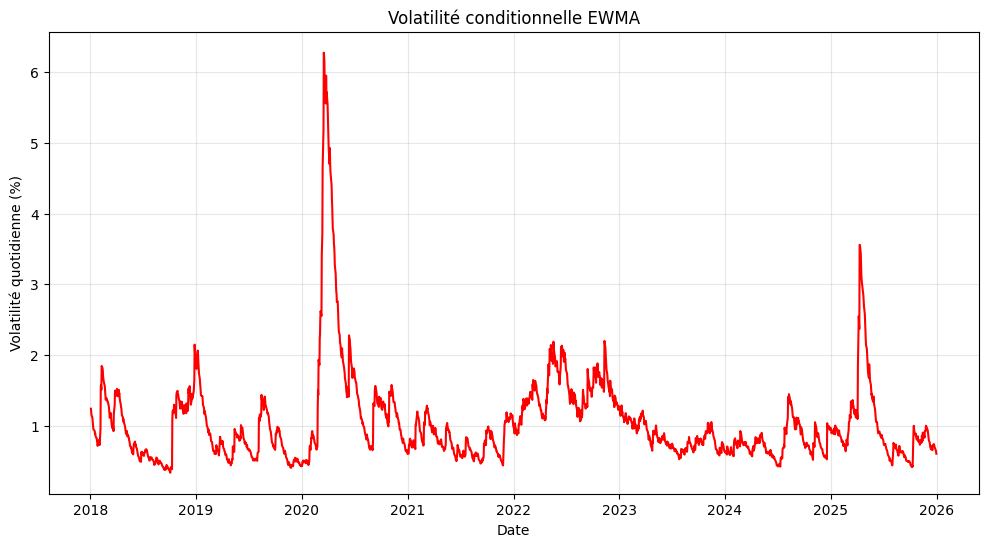

In [173]:
# Graphique de volatilité EWMA
plt.figure(figsize=(12, 6))

plt.plot(ewma_vol.index,ewma_vol * 100,color="red")

plt.title("Volatilité conditionnelle EWMA")
plt.xlabel("Date")
plt.ylabel("Volatilité quotidienne (%)")
plt.grid(alpha=0.3)
plt.show()

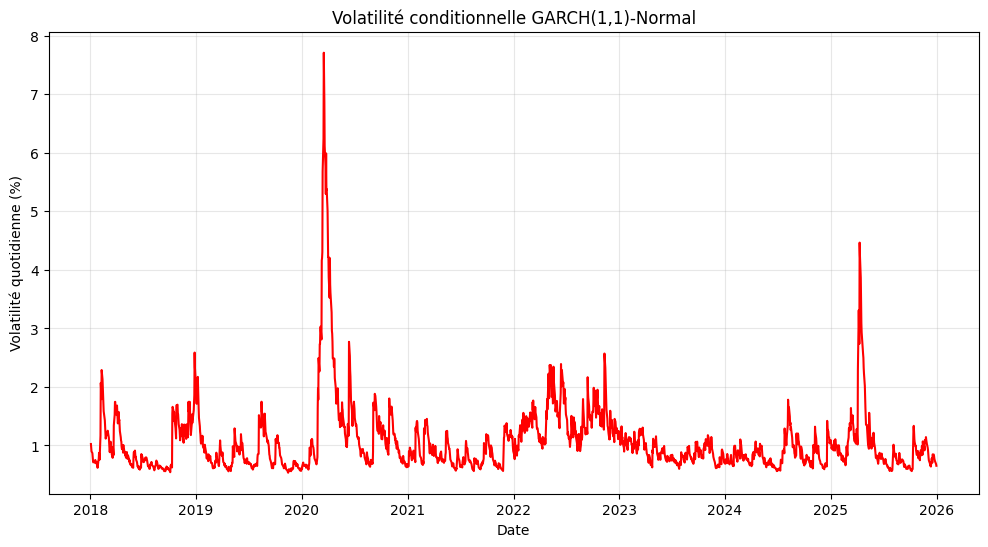

In [174]:
# Graphique de volatilité GARCH-Normal

fitted = garch_normal_result["fitted_model"]
garch_vol = fitted.conditional_volatility
plt.figure(figsize=(12, 6))
plt.plot(garch_vol.index, garch_vol,color="red")
plt.title("Volatilité conditionnelle GARCH(1,1)-Normal")
plt.xlabel("Date")
plt.ylabel("Volatilité quotidienne (%)")
plt.grid(alpha=0.3)
plt.show()

In [175]:
def ewma_var_series(returns,portfolio_value,confidence=0.99,lamb=lamba1):
    """
    Calcule une série historique de VaR EWMA.
    """

    # Calcul de la volatilité EWMA
    vol = ewma_volatility(returns,lamb)

    # Quantile de la loi normale
    z = norm.ppf(confidence)
    #VaR en rendement
    var_return = z * vol

    # VaR en valeur monétaire
    var_money = portfolio_value* z * vol
    # Création du DataFrame
    output = pd.DataFrame(
        {
            "Return": returns,
            "Volatility": vol,
            "var": var_return,
            "VaR_Money": var_money
        }
    )

    return output

In [176]:
ewma_history = ewma_var_series(returns,portfolio_value=1_000_000, confidence=0.99)


In [177]:
ewma_history.head()

,Return,Volatility,var,VaR_Money
Date,,,,
2018-01-03,0.006378,0.012382,0.028805,28804.671793
2018-01-04,0.004021,0.011958,0.027819,27819.264729
2018-01-05,0.007009,0.011463,0.026666,26665.975741
2018-01-08,0.001661,0.011129,0.025891,25890.536487
2018-01-09,0.001302,0.010620,0.024705,24704.738718


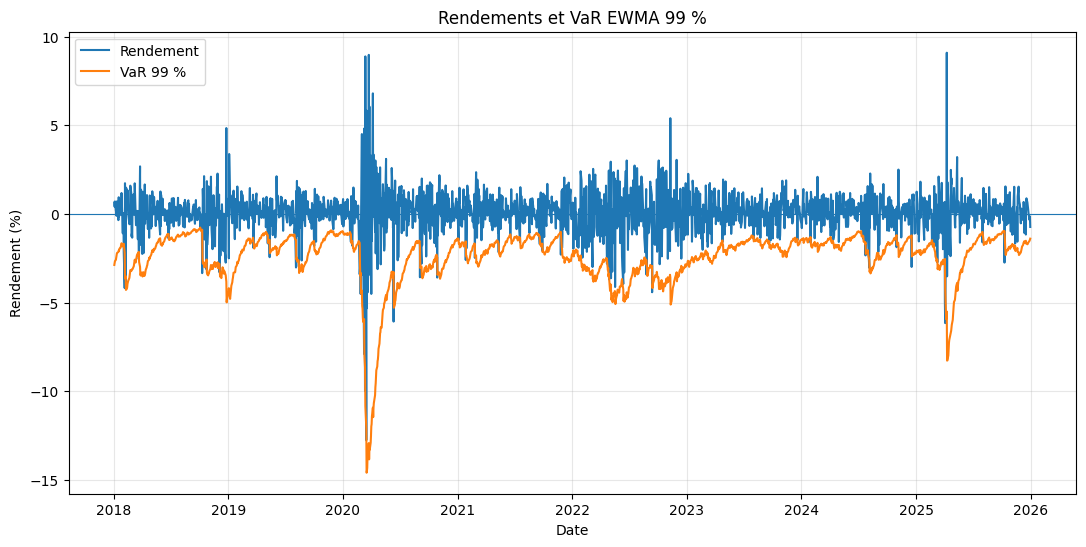

In [178]:
plt.figure(figsize=(13, 6))

plt.plot(ewma_history.index,ewma_history["Return"] * 100, label="Rendement")

plt.plot(ewma_history.index,-ewma_history["var"] * 100,label="VaR 99 %")

plt.axhline(0,linewidth=0.8)

plt.title("Rendements et VaR EWMA 99 %")
plt.ylabel("Rendement (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [179]:
# Actifs
tickers = ["AAPL","MSFT","GOOGL","AMZN"]

data_assets = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)
prices_assets = data_assets["Close"]
prices_assets = prices_assets.dropna()



[*********************100%***********************]  4 of 4 completed


In [180]:
prices_assets.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2018-01-02,40.232384,59.450500,53.188862,78.552017
2018-01-03,40.225353,60.209999,54.096317,78.917618
2018-01-04,40.412216,60.479500,54.306450,79.612198
2018-01-05,40.872322,61.457001,55.026566,80.599258
2018-01-08,40.720528,62.343498,55.220840,80.681488


In [181]:

#Calcul des rendements logarithmiques
asset_returns = np.log(prices_assets / prices_assets.shift(1)).dropna()
asset_returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2018-01-03,-0.000175,0.012694,0.016917,0.004643
2018-01-04,0.004635,0.004466,0.003877,0.008763
2018-01-05,0.011321,0.016033,0.013173,0.012322
2018-01-08,-0.003721,0.014322,0.003524,0.001020
2018-01-09,-0.000115,0.004665,-0.001275,-0.000680


In [182]:
 #Fonction de calcul du rendement du portefeuille
def portfolio_returns(asset_returns,weights):
    weights = np.asarray(weights)

    if len(weights) != asset_returns.shape[1]:
        raise ValueError("Le nombre de poids doit " "correspondre au nombre d'actifs.")

    return asset_returns.dot(weights)
weights = np.array([ 0.40,0.30,0.20,0.10])



In [183]:
# Calcul des rendements du portefeuille
port_returns = portfolio_returns(asset_returns,weights)
port_returns.head()

,0
Date,
2018-01-03,0.007586
2018-01-04,0.004845
2018-01-05,0.013205
2018-01-08,0.003615
2018-01-09,0.001030


In [184]:
#Calcul de la VaR GARCH-Normal
result = garch_var_normal(port_returns,portfolio_value=5_000_000,confidence=0.99)
print("=" * 30)
print(" VaR-MODÈLE GARCH(1,1)-NORMAL")
print("=" * 30)

print(f"\nModèle                : {result['model']}")
print(f"Niveau de confiance   : {result['confidence']:.0%}")

print("\n--- Prévisions ---")
print(f"Rendement moyen prévu : {result['mean_forecast']:.4%}")
print(f"Volatilité prévue      : {result['forecast_volatility']:.4%}")

print("\n--- Paramètres GARCH ---")
print(f"Omega (ω)              : {result['omega']:.6f}")
print(f"Alpha (α)              : {result['alpha']:.6f}")
print(f"Beta  (β)              : {result['beta']:.6f}")
print(f"Persistance (α + β)    : {result['persistence']:.6f}")

print("\n--- Value at Risk ---")
print(f"VaR en rendement       : {result['VaR_return']:.4%}")
print(f"VaR monétaire          : {result['VaR_money']:,.2f} €")

print("\n" + "=" * 55)

 VaR-MODÈLE GARCH(1,1)-NORMAL

Modèle                : GARCH(1,1)-Normal
Niveau de confiance   : 99%

--- Prévisions ---
Rendement moyen prévu : 0.1366%
Volatilité prévue      : 0.9945%

--- Paramètres GARCH ---
Omega (ω)              : 0.096611
Alpha (α)              : 0.113750
Beta  (β)              : 0.852776
Persistance (α + β)    : 0.966527

--- Value at Risk ---
VaR en rendement       : 2.1769%
VaR monétaire          : 108,847.36 €

